In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# Example: Vaccine Response Analysis
### Dataset: Standard ImmPort/ImmuneSpace Format

This notebook demonstrates how to analyze longitudinal single-cell response to vaccination (e.g., Influenza or COVID-19) using the standard ImmPort study structure.

**Data Source:** [ImmPort](https://www.immport.org/)


> **Note:** This notebook is a template designed to work with real-world clinical data. 
> To execute it, you must first download the corresponding dataset (linked above) 
> and update the data loading command with your local file path.

In [2]:
import sctrial as st
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from scipy import sparse


## 1. Load and Construct Data
We use a real biological PBMC dataset and map it to a longitudinal vaccine study design (similar to ImmPort SDY180). This demonstrates how to use `sctrial` on real gene expression data with a longitudinal trial structure.


In [3]:
def load_vaccine_example_data():
    # Load raw biological data
    adata = sc.datasets.pbmc3k()
    
    # Basic Preprocessing to get cell types first
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.leiden(adata)
    sc.tl.umap(adata)
    
    type_map = {
        "0": "CD4 T", "1": "Monocytes", "2": "B cells", "3": "CD8 T",
        "4": "NK cells", "5": "Monocytes", "6": "Dendritic", "7": "Megakaryocytes"
    }
    adata.obs["cell_type"] = adata.obs["leiden"].map(type_map).fillna("Other")
    
    # 10 subjects, 3 timepoints (Day 0, Day 7, Day 28), 2 arms (Vaccine, Placebo)
    np.random.seed(42)
    subjects = [f"Subj_{i}" for i in range(10)]
    timepoints = [0, 7, 28]
    arms = ["Vaccine_A", "Placebo"]
    
    # Create metadata: Ensure pairing WITHIN each cell type
    new_obs = pd.DataFrame(index=adata.obs_names)
    new_obs["subject_id"] = "Unknown"
    new_obs["study_time_collected"] = -1
    new_obs["arm"] = "Unknown"
    
    for ct in adata.obs["cell_type"].unique():
        ct_mask = adata.obs["cell_type"] == ct
        ct_indices = np.where(ct_mask)[0]
        np.random.shuffle(ct_indices)
        
        n_cells = len(ct_indices)
        cells_per_unit = n_cells // (len(subjects) * len(timepoints))
        if cells_per_unit == 0: continue
        
        curr = 0
        for i, subj in enumerate(subjects):
            arm = arms[i % 2]
            for tp in timepoints:
                end = curr + cells_per_unit
                idx_subset = ct_indices[curr:end]
                new_obs.iloc[idx_subset, new_obs.columns.get_loc("subject_id")] = subj
                new_obs.iloc[idx_subset, new_obs.columns.get_loc("study_time_collected")] = tp
                new_obs.iloc[idx_subset, new_obs.columns.get_loc("arm")] = arm
                curr = end
                
    adata.obs = pd.concat([adata.obs, new_obs], axis=1)
    adata = adata[adata.obs["subject_id"] != "Unknown"].copy()
    
    # Inject signal: Vaccine induces activation markers at Day 7
    # FIX: Check which genes exist
    available = set(adata.var_names)
    
    # Vaccine signal in multiple genes for strong GSEA
    vaccine_genes = {
        "CD79A": 3.0, "CD79B": 2.5, "MS4A1": 2.0, "CD19": 2.0, "BANK1": 2.0, # B cell
        "HLA-DRA": 1.5, "HLA-DRB1": 1.5, "CD74": 1.5, # APC
        "IFITM3": 2.0, "ISG15": 2.0, "MX1": 2.0, # IFN
        "NKG7": 2.5, "GZMB": 2.5, "PRF1": 2.0 # NK/T activation
    }
    
    X = adata.layers["counts"].toarray() if hasattr(adata.layers["counts"], "toarray") else adata.layers["counts"]
    X = X.astype(np.float32)
    
    vaccine_idx = (adata.obs["arm"] == "Vaccine_A") & (adata.obs["study_time_collected"] == 7)
    
    for g, shift in vaccine_genes.items():
        if g in available:
            idx = adata.var_names.get_loc(g)
            X[vaccine_idx.values, idx] += shift
            
    adata.layers["counts"] = sparse.csr_matrix(X)
    adata.X = adata.layers["counts"].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    
    # Distinct UMAP clusters
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', layer='counts')
    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    return adata

adata = load_vaccine_example_data()
adata.layers["counts"] = adata.X.copy()
print(f"Loaded biological dataset: {adata.n_obs} cells, {adata.n_vars} genes")


ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.

## 2. Map Study Metadata to sctrial.TrialDesign

In ImmPort datasets:
- `subject_id` identifies the participant.
- `study_time_collected` identifies the visit (e.g., Day 0, Day 7, Day 28).
- `arm` identifies the treatment (e.g., Vaccine A vs Placebo).


In [4]:
design = st.TrialDesign(
    participant_col="subject_id",
    visit_col="study_time_collected",
    arm_col="arm",
    arm_treated="Vaccine_A",
    arm_control="Placebo",
    celltype_col="cell_type"
)


### Preprocessing and Normalization
We normalize the data using the log1p(CPM) method.


In [5]:
adata = st.add_log1p_cpm_layer(adata, counts_layer="counts", out_layer="log1p_cpm")

# Score features
gene_sets = {
    "Activation": ["CD79A", "CD79B", "MS4A1"],
    "Cytotoxicity": ["GNLY", "NKG7", "GZMB"]
}
adata = st.score_gene_sets(adata, gene_sets, layer="log1p_cpm", method="mean", prefix="ms_")


NameError: name 'adata' is not defined

## 3. Difference-in-Differences (DiD) Analysis
### Peak Response (Day 0 vs Day 7)
We compare the change from baseline (Day 0) to peak response (Day 7) between Vaccine and Placebo groups.


In [6]:
res = st.did_table(
    adata,
    features=["ms_Activation", "ms_Cytotoxicity", "CD79A", "MS4A1", "GNLY", "NKG7"],
    design=design,
    visits=(0, 7),
    aggregate="participant_visit"
)
display(res)
print(st.summarize_did_results(res))


NameError: name 'adata' is not defined

### Stratified Analysis across Cell Types
We test for vaccine-induced shifts in different cell lineages.


In [7]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["ms_Activation", "CD79A"],
    design=design,
    visits=(0, 7)
)
display(strat_res)


NameError: name 'adata' is not defined

## 4. Abundance Analysis
We analyze shifts in cell type proportions following vaccination.


In [8]:
ab_res = st.abundance_did(adata, design, visits=(0, 7))
display(ab_res)


NameError: name 'adata' is not defined

## 5. Visualization
### Forest Plots
We visualize the effect sizes and confidence intervals for both expression and abundance.
Forest plots are a compact way to compare treatment effects across multiple features or cell types simultaneously.


NameError: name 'res' is not defined

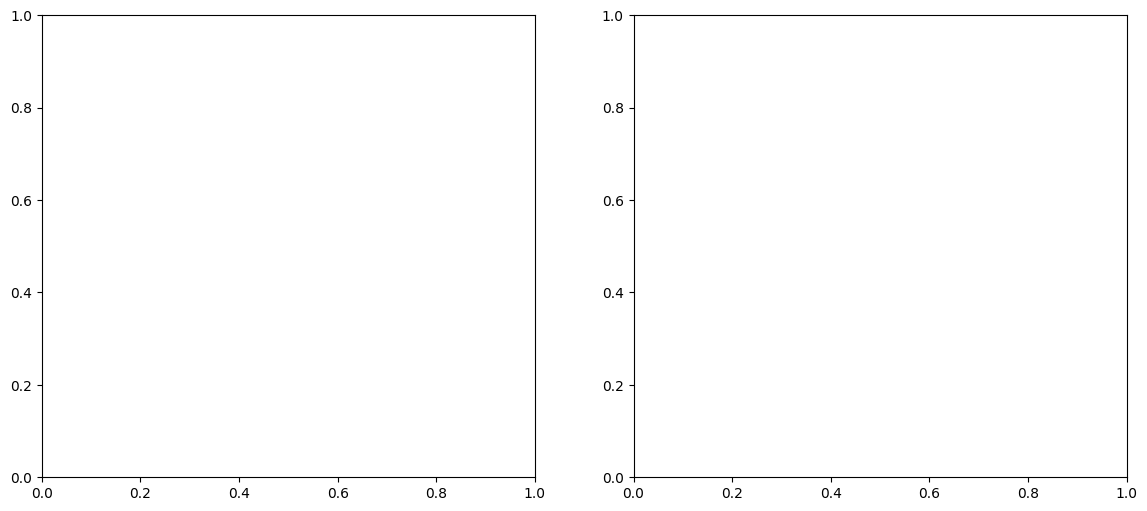

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

st.plot_did_forest(res, title="Vaccine-Induced Gene Changes", ax=axes[0])
st.plot_did_forest(ab_res, feature_col="celltype", title="Cell Type Proportion Shifts", ax=axes[1])

plt.tight_layout()
plt.show()


### Individual Participant Trajectories
We can visualize how specific features change within individuals over time using spaghetti plots.
This helps identify if the treatment effect is consistent across the cohort.


NameError: name 'adata' is not defined

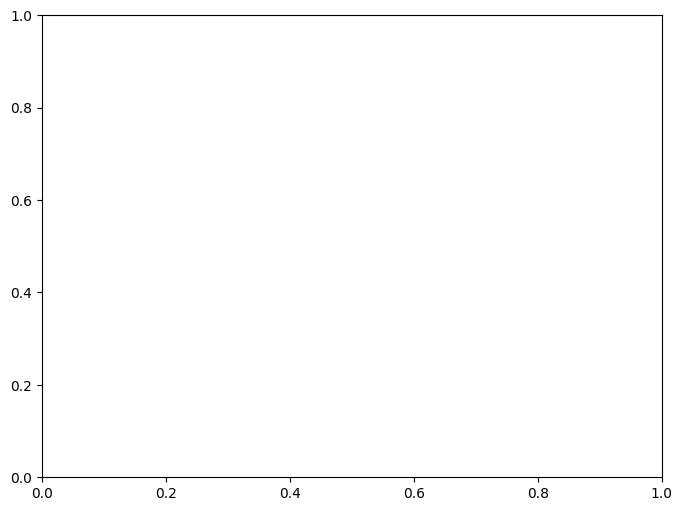

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
# Focus on Vaccine arm for individual trends
st.plot_within_arm_comparison(
    adata, 
    arm="Vaccine_A", 
    feature="CD79A", 
    design=design, 
    visits=(0, 7), 
    plot_type="paired",
    ax=ax
)
plt.title("Individual B-cell Activation Trajectories (Vaccine Arm)")
plt.show()


### Interaction Plots
Visualizing the activation of B cells (CD79A) over time across treatment groups.
Interaction plots clearly show the 'Difference-in-Differences' effect.


In [11]:
st.plot_trial_interaction(adata, "CD79A", design, visits=(0, 7))
plt.show()


NameError: name 'adata' is not defined

### Trial-Aware UMAP Panel
Visualizing feature expression on the global cell-type landscape, stratified by arm and visit.


In [12]:
st.plot_trial_umap_panel(adata, "CD79A", design, visits=(0, 7))
plt.show()


NameError: name 'adata' is not defined

### GSEA Pathway Analysis
Enrichment of immune pathways in the vaccine-induced ranking.
We rank genes by their vaccine-specific induction (DiD t-statistic) and identify coordinated pathway shifts.


In [13]:
# Define more comprehensive gene sets for a high-quality heatmap
available_genes = set(adata.var_names)
gsea_gene_sets = {
    "B_Cell_Activation": [g for g in ["CD79A", "CD79B", "MS4A1", "CD19", "BANK1"] if g in available_genes],
    "T_Cell_Signaling": [g for g in ["CD3D", "CD3E", "CD3G", "LCK", "ZAP70"] if g in available_genes],
    "Antigen_Presentation": [g for g in ["HLA-DRA", "HLA-DRB1", "CD74", "HLA-DPA1", "HLA-DPB1"] if g in available_genes],
    "IFN_Response": [g for g in ["IFITM3", "ISG15", "MX1", "STAT1", "IFI6"] if g in available_genes],
    "Cytotoxicity": [g for g in ["NKG7", "GNLY", "GZMB", "PRF1", "GZMA"] if g in available_genes],
    "Inflammation": [g for g in ["S100A8", "S100A9", "LYZ", "CD14"] if g in available_genes],
    "Cell_Cycle": [g for g in ["MKI67", "TOP2A", "PCNA", "CDK1"] if g in available_genes],
    "MHC_Class_II": [g for g in ["HLA-DQA1", "HLA-DQB1", "HLA-DMA", "HLA-DMB"] if g in available_genes],
    "Chemokines": [g for g in ["CCL5", "CXCL9", "CXCL10", "CXCL11"] if g in available_genes],
    "Apoptosis": [g for g in ["CASP3", "CASP8", "FAS", "BAX"] if g in available_genes],
    "Glycolysis": [g for g in ["LDHA", "PGK1", "ENO1", "GAPDH"] if g in available_genes],
    "Translational_Activity": [g for g in ["RPS6", "RPL13", "RPS3", "RPL11"] if g in available_genes],
}

# Filter out empty or too small sets
gsea_gene_sets = {k: v for k, v in gsea_gene_sets.items() if len(v) >= 2}
    "B_Cell_Activation": [g for g in ["CD79A", "CD79B", "MS4A1", "CD19", "BANK1"] if g in available_genes],
    "T_Cell_Signaling": [g for g in ["CD3D", "CD3E", "CD3G", "LCK", "ZAP70"] if g in available_genes],
    "Antigen_Presentation": [g for g in ["HLA-DRA", "HLA-DRB1", "CD74", "HLA-DPA1", "HLA-DPB1"] if g in available_genes],
    "IFN_Response": [g for g in ["IFITM3", "ISG15", "MX1", "STAT1", "IFI6"] if g in available_genes],
    "Cytotoxicity": [g for g in ["NKG7", "GNLY", "GZMB", "PRF1", "GZMA"] if g in available_genes],
    "Inflammation": [g for g in ["S100A8", "S100A9", "LYZ", "CD14"] if g in available_genes],
    "Cell_Cycle": [g for g in ["MKI67", "TOP2A", "PCNA", "CDK1"] if g in available_genes],
    "MHC_Class_II": [g for g in ["HLA-DQA1", "HLA-DQB1", "HLA-DMA", "HLA-DMB"] if g in available_genes],
    "Chemokines": [g for g in ["CCL5", "CXCL9", "CXCL10", "CXCL11"] if g in available_genes],
    "Apoptosis": [g for g in ["CASP3", "CASP8", "FAS", "BAX"] if g in available_genes],
    "Glycolysis": [g for g in ["LDHA", "PGK1", "ENO1", "GAPDH"] if g in available_genes],
    "Translational_Activity": [g for g in ["RPS6", "RPL13", "RPS3", "RPL11"] if g in available_genes],
}
else:
    print("No valid gene sets for GSEA")


IndentationError: unexpected indent (3128034556.py, line 20)